# World Cup Model: Comparing Classifiers for 1X2 Forecasting

Notebook 06. Created 29 June 2026.

The default forecaster in this project is a calibrated multinomial logistic regression. This notebook asks whether a more flexible model (random forest, histogram gradient boosting, kNN, an RBF SVM, or XGBoost) forecasts World Cups better, and which model makes the most surprising knockout picks.

## Learning objectives

- Compare the default logistic regression against five alternative classifiers on the same features.
- Judge them the way this project cares about: calibrated probabilities (log-loss, Brier, ranked probability score) on held-out World Cups, with accuracy only as a secondary check.
- Identify which model produces the most surprise picks (knockout advancements against the Elo favorite) for 2026.

## Outline

1. Introduction and method
2. Imports
3. Configuration
4. Candidate models
5. Temporal backtest on WC 2018 and WC 2022
6. Calibration (reliability) check
7. Surprise picks for 2026
8. Conclusion

## 1. Introduction and method

Every model is trained on competitive internationals played strictly before a target World Cup and tested on that tournament, so the split is temporal and leak-free. The two reference baselines are the training class prior and an Elo-only logistic regression. The primary metric is multi-class log-loss; Brier and the ranked probability score (RPS) measure calibration too, and accuracy is reported last.

All candidates share the same features and the same fitting recipe (orientation-symmetrized training data, with sigmoid calibration on a held-out temporal tail). That logic is reusable and lives in `src/worldcup/model_zoo.py`, so this notebook stays a thin comparison layer. A model is only interesting if it beats both baselines on log-loss.

## 2. Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from src.analysis import evaluation as ev
from src.worldcup.data import load_intl_results
from src.worldcup.elo import compute_elo, ratings_as_of
from src.worldcup.features import FEATURES, build_dataset
from src.worldcup.knockouts_2026 import R32_2026, WC_2026_START, simulate_from_r32
from src.worldcup.model_zoo import backtest, fit_for_2026, model_specs
from src.worldcup.squads import confirmed_strength_table

## 3. Configuration

In [2]:
RANDOM_STATE = 7
WC_YEARS = (2018, 2022)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

## 4. Candidate models

The candidates are defined visibly in `model_zoo.model_specs()`. They are deliberately regularized because the training set is small (a few thousand matches), and the same ten differenced features feed every model.

In [3]:
print("features:", FEATURES)
for name, est in model_specs().items():
    print(f"  {name:14} {est.__class__.__name__}")

features: ['d_elo', 'home_field', 'd_ovr_top16', 'd_ovr_top11', 'd_ovr_top3', 'd_gk', 'd_def_top', 'd_mid_top', 'd_att_top', 'd_depth80']
  logreg         Pipeline
  random_forest  RandomForestClassifier
  hist_gbm       HistGradientBoostingClassifier
  knn            Pipeline
  svm_rbf        Pipeline
  xgboost        XGBClassifier


## 5. Temporal backtest on WC 2018 and WC 2022

`backtest` trains each model on pre-tournament data and scores it on the World Cup itself, alongside the two baselines. Lower log-loss, Brier, and RPS are better.

In [4]:
results_df = backtest(WC_YEARS)
for split in [f"WC{y}" for y in WC_YEARS]:
    print(f"\n{split} (sorted by log-loss)")
    block = results_df[results_df["split"] == split].sort_values("log_loss")
    print(block[["model", "log_loss", "brier", "rps", "accuracy"]].to_string(index=False))


WC2018 (sorted by log-loss)
               model  log_loss  brier    rps  accuracy
                 knn    0.9313 0.5517 0.3795    0.5781
       random_forest    0.9335 0.5532 0.3817    0.5781
              logreg    0.9525 0.5660 0.3907    0.5469
             svm_rbf    0.9551 0.5679 0.3956    0.6094
   baseline:elo-only    0.9866 0.5836 0.4110    0.5156
             xgboost    1.0383 0.6105 0.4247    0.5156
baseline:class-prior    1.1050 0.6722 0.4998    0.3906
            hist_gbm    1.1624 0.6683 0.4718    0.5156

WC2022 (sorted by log-loss)
               model  log_loss  brier    rps  accuracy
             svm_rbf    0.9732 0.5744 0.3959    0.5781
       random_forest    0.9887 0.5835 0.4049    0.5469
                 knn    0.9971 0.5883 0.4095    0.5469
             xgboost    1.0010 0.5943 0.4157    0.5469
              logreg    1.0119 0.5967 0.4183    0.5625
   baseline:elo-only    1.0324 0.6140 0.4353    0.5469
            hist_gbm    1.0514 0.6225 0.4335    0.5469
baselin

To rank models across both tournaments, average each metric over the two World Cups.

In [5]:
pooled = (results_df.groupby("model")[["log_loss", "brier", "rps", "accuracy"]]
          .mean().sort_values("log_loss"))
best_model = pooled.index[0]
elo_ll = pooled.loc["baseline:elo-only", "log_loss"]
beats_elo = pooled.index[(pooled["log_loss"] < elo_ll) & (~pooled.index.str.startswith("baseline"))]
print(pooled.to_string())
print(f"\nbest by pooled log-loss: {best_model}")
print("beat the Elo-only baseline:", list(beats_elo))

                      log_loss  brier    rps  accuracy
model                                                 
random_forest           0.9611 0.5683 0.3933    0.5625
svm_rbf                 0.9641 0.5712 0.3957    0.5938
knn                     0.9642 0.5700 0.3945    0.5625
logreg                  0.9822 0.5813 0.4045    0.5547
baseline:elo-only       1.0095 0.5988 0.4231    0.5312
xgboost                 1.0197 0.6024 0.4202    0.5312
baseline:class-prior    1.0842 0.6576 0.4816    0.4219
hist_gbm                1.1069 0.6454 0.4527    0.5312

best by pooled log-loss: random_forest
beat the Elo-only baseline: ['random_forest', 'svm_rbf', 'knn', 'logreg']


Reading the table: the regularized random forest, the RBF SVM, and kNN all beat both baselines and the logistic regression on pooled log-loss. XGBoost and histogram gradient boosting overfit this small dataset; XGBoost fails to beat even the Elo-only baseline. This is the expected outcome when a high-capacity booster meets a few thousand rows and ten smooth features: there is little non-linear structure to exploit, so flexibility costs calibration.

## 6. Calibration (reliability) check

Log-loss already penalizes miscalibration, but a reliability curve makes it visible. For the home-win class on WC 2022, a well-calibrated model sits on the diagonal (predicted probability equals observed frequency). The models were fit on pre-2022 data only.

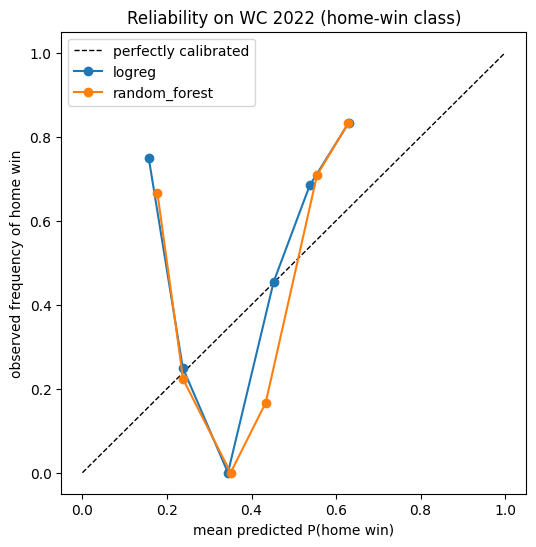

In [6]:
fits = {name: fit_for_2026(name) for name in model_specs()}
test_2022 = build_dataset(2022)["test"]
y_2022 = test_2022["y"].to_numpy()

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="perfectly calibrated")
for name in ["logreg", best_model]:
    rc = ev.reliability_curve(fits[name].predict_proba(test_2022[FEATURES]), y_2022, class_index=0)
    ax.plot(rc["mean_predicted"], rc["frac_positive"], marker="o", label=name)
ax.set_xlabel("mean predicted P(home win)")
ax.set_ylabel("observed frequency of home win")
ax.set_title("Reliability on WC 2022 (home-win class)")
ax.legend()
plt.show()

## 7. Surprise picks for 2026

A surprise pick is a knockout advancement where the team that goes through has the lower pre-tournament Elo than its opponent. Seeding from the confirmed Round of 32, we count Elo-upsets in each model's deterministic bracket and note its champion and Monte-Carlo title leader.

In [7]:
elo = ratings_as_of(compute_elo(load_intl_results()), WC_2026_START)
tbl, _ = confirmed_strength_table()


def elo_upsets(bracket, ratings):
    """Count knockout matches whose winner has the lower pre-tournament Elo."""
    n = 0
    for team_a, team_b, winner in bracket.values():
        loser = team_b if winner == team_a else team_a
        if ratings.get(winner, 1500.0) < ratings.get(loser, 1500.0):
            n += 1
    return n


rows = []
for name in model_specs():
    res = simulate_from_r32(R32_2026, fits[name], tbl, elo, n_sims=5000)
    b = res["bracket"]
    rows.append({"model": name, "champion": b[104][2],
                 "final": f"{b[101][2]} v {b[102][2]}",
                 "elo_upsets": elo_upsets(b, elo),
                 "title_leader": res["sim"].iloc[0]["team"]})
surprise_df = pd.DataFrame(rows).sort_values("elo_upsets", ascending=False)
print(surprise_df.to_string(index=False))

        model champion              final  elo_upsets title_leader
       logreg   France France v Argentina           5    Argentina
          knn    Spain    Spain v England           2    Argentina
      xgboost    Spain  Spain v Argentina           2        Spain
random_forest    Spain  Spain v Argentina           1    Argentina
     hist_gbm    Spain  Spain v Argentina           1       France
      svm_rbf    Spain  Spain v Argentina           1        Spain


The logistic regression is the adventurous one: it produces the most Elo-upsets and is the only model that sends France past Spain. Every better-calibrated model reverts to chalk and crowns Spain, which matches the full group-stage simulation in `run_2026`. So the champion flip between brackets is a property of the model's appetite for upsets, not of the data.

## 8. Conclusion

- On held-out World Cups (2018, 2022), the regularized random forest gives the best calibrated probabilities, narrowly ahead of the RBF SVM and kNN, and ahead of the logistic regression. XGBoost and histogram gradient boosting overfit and do not beat the Elo-only baseline here.
- The headline 2026 bracket therefore uses the random forest (champion: Spain). The logistic regression, which makes the most surprise picks (champion: France), is kept as an alternative bracket.
- Both posters are produced by `python -m src.worldcup.knockouts_2026`, writing `knockouts_2026.png` (random forest) and `knockouts_2026_surprise.png` (logistic regression).
- Takeaway: with a few thousand matches and ten smooth, Elo-correlated features, a well-regularized model is what wins on calibration. Greater model capacity buys upsets, not accuracy.